In [1]:
suppressMessages({
    library(dplyr)
    library(ggplot2)
    library(tidyverse)
    library(slider)
    library(pROC)
    library(xgboost)
    library(Matrix)
    library(nnet)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘slider’ was built under R version 4.4.3”


### Load Data

In [2]:
wildfires <- read_csv("wildfires_sample_100k.csv") %>% 
  select(FIRE_YEAR, DISCOVERY_DOY, FIRE_SIZE, LATITUDE, LONGITUDE, STATE) %>%
  mutate(STATE = as.factor(STATE))

glimpse(wildfires)

Rows: 100000 Columns: 39
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (27): FPA_ID, SOURCE_SYSTEM_TYPE, SOURCE_SYSTEM, NWCG_REPORTING_AGENCY, ...
dbl (12): OBJECTID, FOD_ID, FIRE_YEAR, DISCOVERY_DATE, DISCOVERY_DOY, STAT_C...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 100,000
Columns: 6
$ FIRE_YEAR     <dbl> 2004, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20…
$ DISCOVERY_DOY <dbl> 277, 186, 182, 147, 202, 148, 172, 107, 108, 199, 117, 2…
$ FIRE_SIZE     <dbl> 0.10, 0.10, 3.00, 0.10, 0.10, 0.10, 0.50, 12.00, 5.00, 3…
$ LATITUDE      <dbl> 38.56417, 48.40778, 48.89444, 37.04417, 36.90000, 33.660…
$ LONGITUDE     <dbl> -120.54222, -115.55778, -115.16528, -119.34389, -107.328…
$ STATE         <fct> CA, MT, MT, CA, NM, AZ, AZ, MN, TX, AZ, AZ, AZ, NM, CO, …


### Temporal Patterns

In [3]:
fires <- wildfires %>% 
    mutate(FIRE_DATE = as.Date(paste(FIRE_YEAR, DISCOVERY_DOY, sep = "-"), format = "%Y-%j"),
          YEAR = year(FIRE_DATE),
          MONTH = month(FIRE_DATE))

### Notable Fire Threshold

In [4]:
notable_threshold_acres <- 300

####### REFERENCE CODE!!!
#df1 <- tips_df |>
#  filter(total_bill > 20)

######### FILL IN THE MISSING PARTS #########
# notable_fires <- fires %>% ...

#########
notable_fires <- fires %>%
  filter(FIRE_SIZE >= notable_threshold_acres)

cat("Number of notable fires:", nrow(notable_fires))

Number of notable fires: 1381

### Spatial Patterns

In [5]:
# ---- Create grid IDs and month index ----
notable_fires <- notable_fires %>%
  mutate(
    lat_bin = floor(LATITUDE),
    lon_bin = floor(LONGITUDE),
    ym = YEAR * 100 + MONTH   # e.g., 201507
  )
### REFERENCE CODE:

#tips_summary <- tips2 |>
#  group_by(day) |>
#  summarise(
#    mean_tip_pct = mean(tip_pct),
#    n = n()
#  )

#tips_summary

# Fire indicator at (grid, month): did any notable fire occur?
#notable means that it is $/ge 300$ acres
grid_month_fire <- notable_fires %>%
  group_by(lat_bin, lon_bin, ym) %>%
  summarise(
    n_fires = n(),
    fire_this_month = as.integer(n() > 0),
    .groups = "drop")
#########

head(grid_month_fire)
summary(grid_month_fire)

lat_bin,lon_bin,ym,n_fires,fire_this_month
<dbl>,<dbl>,<dbl>,<int>,<int>
17,-67,200407,1,1
18,-68,200906,1,1
18,-67,200503,1,1
19,-156,199210,1,1
19,-156,199910,1,1
19,-156,200706,1,1


    lat_bin         lon_bin             ym            n_fires     
 Min.   :17.00   Min.   :-165.0   Min.   :199201   Min.   :1.000  
 1st Qu.:33.00   1st Qu.:-117.0   1st Qu.:200002   1st Qu.:1.000  
 Median :37.00   Median :-107.0   Median :200509   Median :1.000  
 Mean   :38.76   Mean   :-107.7   Mean   :200444   Mean   :1.053  
 3rd Qu.:43.00   3rd Qu.: -96.0   3rd Qu.:200908   3rd Qu.:1.000  
 Max.   :69.00   Max.   : -67.0   Max.   :201511   Max.   :3.000  
 fire_this_month
 Min.   :1      
 1st Qu.:1      
 Median :1      
 Mean   :1      
 3rd Qu.:1      
 Max.   :1      

In [6]:
# ---- Build panel (all grid cells that appear at least once) ----
all_grids <- grid_month_fire %>% distinct(lat_bin, lon_bin)

# Generate a safe monthly sequence using actual dates
start_date <- ymd(paste0(min(grid_month_fire$ym) %/% 100, "-", min(grid_month_fire$ym) %% 100, "-01"))
end_date   <- ymd(paste0(max(grid_month_fire$ym) %/% 100, "-", max(grid_month_fire$ym) %% 100, "-01"))

all_months <- tibble(date = seq.Date(start_date, end_date, by = "month")) %>%
  mutate(year = year(date), month = month(date), ym = year * 100 + month) %>%
  select(ym, year, month)

# Full panel = grid × month

### TIDYVERSE DOCUMENTATION
#crossing(..., .name_repair = "check_unique")

#ymd(20101215)
#mdy("4/1/17")

######### FILL IN THE MISSING PARTS #########
# panel <- crossing(all_grids, all_months) %>% ...
panel <- crossing(all_grids, all_months) %>%
  left_join(grid_month_fire, by = c("lat_bin", "lon_bin", "ym")) %>%
  mutate(n_fires = replace_na(n_fires, 0),fire_this_month = replace_na(fire_this_month, 0))

#########

glimpse(panel)

Rows: 148,092
Columns: 7
$ lat_bin         <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin         <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67,…
$ ym              <dbl> 199201, 199202, 199203, 199204, 199205, 199206, 199207…
$ year            <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, …
$ month           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ n_fires         <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ fire_this_month <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


### Prediction Target

In [7]:
panel <- panel %>%
  arrange(lat_bin, lon_bin, ym) %>%
  group_by(lat_bin, lon_bin) %>%
  mutate(
    y_next = lead(fire_this_month, n = 1L)
  ) %>%
  ungroup() %>%
  filter(!is.na(y_next))

table(panel$y_next)


     0      1 
146265   1311 

### Baseline Predictors

In [8]:
######### FILL IN THE MISSING PARTS #########
# mode_state <- function(x) { ...

#if multiple states appear, choose the majority state
#Sample code:
 # Example data for using the which.max function
 #numeric_vector <- c(3, 8, 2, 10, 5)
 
 # Use which.max to find the index of the first maximum value
 #max_index <- which.max(numeric_vector)
 
 # Display the result
 #print(max_index)

mode_state <- function(x) {
  uniq_x <- unique(x)
  uniq_x[which.max(tabulate(match(x, uniq_x)))]
}

# grid_state <- notable_fires %>% ...

grid_state <- notable_fires %>%
  group_by(lat_bin, lon_bin) %>%
  summarise(state = mode_state(STATE), .groups = "drop")

#########

panel <- panel %>%
  left_join(grid_state, by = c("lat_bin","lon_bin"))

panel %>% select('state') %>% summary

     state      
 AK     :17732  
 TX     :16016  
 CA     :10582  
 MT     : 8294  
 NM     : 8294  
 OR     : 6578  
 (Other):80080  

### Seasonality: Cyclical Month Encoding

In [9]:
######### FILL IN THE MISSING PARTS #########
# panel <- panel %>% ..


#https://lubridate.tidyverse.org/reference/cyclic_encoding.html
## CYCLIC ENCODING
#cyclic_encoding(
#  x,
#  periods,
#  encoders = c("sin", "cos"),
#  week_start = getOption("lubridate.week.start", 7)
#)

panel <- panel %>%
  mutate(
    month_sin = sin(2 * pi * month / 12),
    month_cos = cos(2 * pi * month / 12)
  )
#########

panel %>% select('month_sin', 'month_cos') %>% head

month_sin,month_cos
<dbl>,<dbl>
5.000000e-01,8.660254e-01
8.660254e-01,5.000000e-01
1.000000e+00,6.123234e-17
8.660254e-01,-5.000000e-01
5.000000e-01,-8.660254e-01
1.224647e-16,-1.000000e+00


### Lagged Fire History

In [10]:
######### FILL IN THE MISSING PARTS #########
# grid_fire_size <- notable_fires %>% ... 

grid_fire_size <- notable_fires %>%
  group_by(lat_bin, lon_bin, ym) %>%
  summarise(fire_size = mean(FIRE_SIZE), .groups = "drop")
#########

panel <- panel %>%
  select(-any_of("fire_size")) %>%
  left_join(grid_fire_size, by = c("lat_bin","lon_bin","ym")) %>%
  mutate(fire_size = coalesce(fire_size, 0))

######### FILL IN THE MISSING PARTS #########
# panel <- panel %>%
#  arrange(lat_bin, lon_bin, ym) %>%
#  group_by(lat_bin, lon_bin) %>% ... 

## SLIDER LIB REFERENCE
#slide_dbl(
#  .x,
#  .f,
#  ...,
#  .before = 0L,
#  .after = 0L,
#  .step = 1L,
#  .complete = FALSE
#)


panel <- panel %>%
  arrange(lat_bin, lon_bin, ym) %>%
  group_by(lat_bin, lon_bin) %>%
  mutate(
    fire_lag12 = lag(n_fires, 12),
    fire_roll3 = slider::slide_dbl(n_fires, sum, .before = 2, .complete = TRUE),
    fire_roll12 = slider::slide_dbl(n_fires, sum, .before = 11, .complete = TRUE),
    size_roll3 = slider::slide_dbl(fire_size, sum, .before = 2, .complete = TRUE),
    size_roll12 = slider::slide_dbl(fire_size, sum, .before = 11, .complete = TRUE)
  ) %>%
  ungroup()

#########

panel %>% 
  select("n_fires", "fire_lag12", "fire_roll3", "fire_roll12", 
         "size_roll3", "size_roll12") %>%
  summary

    n_fires           fire_lag12      fire_roll3      fire_roll12   
 Min.   :0.000000   Min.   :0.000   Min.   :0.0000   Min.   :0.000  
 1st Qu.:0.000000   1st Qu.:0.000   1st Qu.:0.0000   1st Qu.:0.000  
 Median :0.000000   Median :0.000   Median :0.0000   Median :0.000  
 Mean   :0.009351   Mean   :0.009   Mean   :0.0282   Mean   :0.113  
 3rd Qu.:0.000000   3rd Qu.:0.000   3rd Qu.:0.0000   3rd Qu.:0.000  
 Max.   :3.000000   Max.   :3.000   Max.   :5.0000   Max.   :6.000  
                    NA's   :6192    NA's   :1032     NA's   :5676   
   size_roll3        size_roll12      
 Min.   :     0.0   Min.   :     0.0  
 1st Qu.:     0.0   1st Qu.:     0.0  
 Median :     0.0   Median :     0.0  
 Mean   :   130.6   Mean   :   512.6  
 3rd Qu.:     0.0   3rd Qu.:     0.0  
 Max.   :344833.0   Max.   :344833.0  
 NA's   :1032       NA's   :5676      

### Required Output: dataset summary table

In [11]:
dataset_summary <- tibble(
  n_rows = nrow(panel),
  year_min = min(panel$year),
  year_max = max(panel$year),
  spatial_unit = "1° x 1° lat-lon grid (floor bins)",
  temporal_unit = "monthly",
  outcome = "y_next = 1 if any notable fire occurs in grid cell next month",
  predictors = "lat_bin, lon_bin, state, month_cos, month_sin, year, 
    n_fires, fire_lag12, fire_roll3, fire_roll12, 
    size_roll3, size_roll12"
)

dataset_summary

n_rows,year_min,year_max,spatial_unit,temporal_unit,outcome,predictors
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
147576,1992,2015,1° x 1° lat-lon grid (floor bins),monthly,y_next = 1 if any notable fire occurs in grid cell next month,"lat_bin, lon_bin, state, month_cos, month_sin, year, n_fires, fire_lag12, fire_roll3, fire_roll12, size_roll3, size_roll12"


### Exploratory Data Analysis

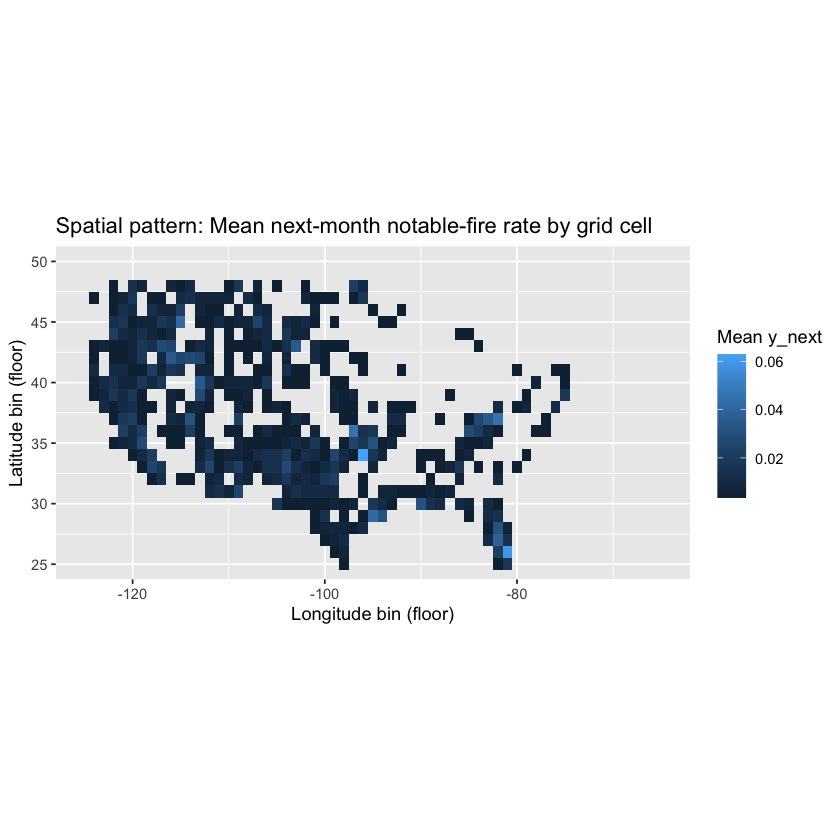

In [12]:
######### FILL IN THE MISSING PARTS #########
# eda_spatial <- panel %>% ...

eda_spatial <- panel %>%
  group_by(lat_bin, lon_bin) %>%
  summarise(
    fire_rate = mean(y_next),
    .groups = "drop"
  )
#########

ggplot(eda_spatial, aes(x = lon_bin, y = lat_bin, fill = fire_rate)) +
  coord_quickmap(xlim = c(-125, -65), ylim = c(25, 50)) + 
  geom_tile() +
  labs(
    title = "Spatial pattern: Mean next-month notable-fire rate by grid cell",
    x = "Longitude bin (floor)",
    y = "Latitude bin (floor)",
    fill = "Mean y_next"
  )

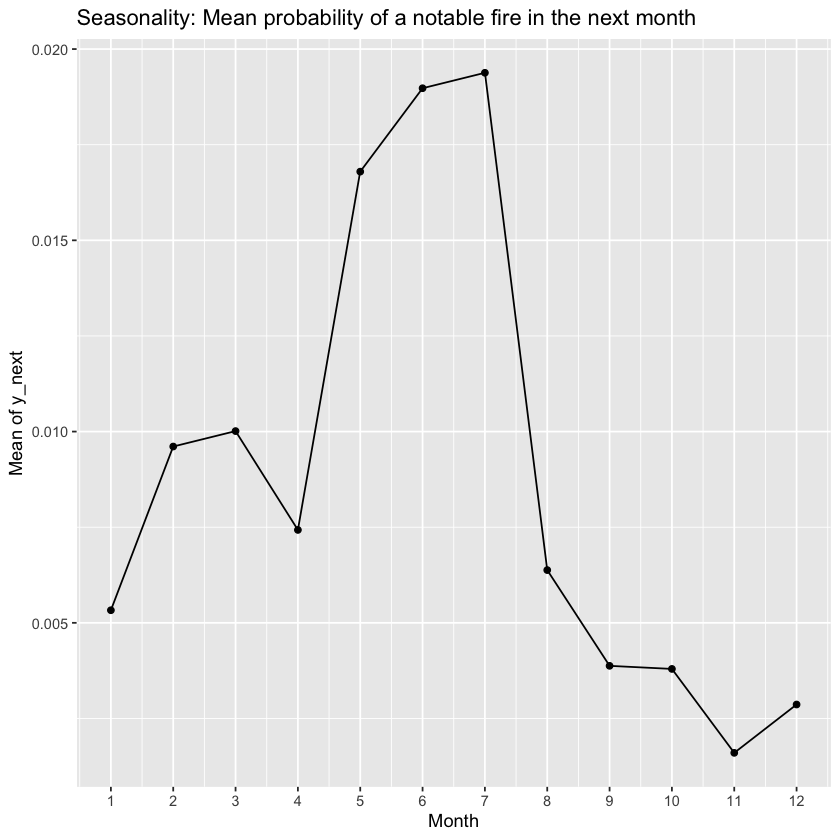

In [13]:
######### FILL IN THE MISSING PARTS #########
# eda_month <- panel %>% ...
eda_month <- panel %>%
  group_by(month) %>%
  summarise(
    mean_y2 = mean(y_next),
    .groups = "drop"
  )

#########

ggplot(eda_month, aes(x = month, y = mean_y2)) +
  geom_line() +
  geom_point() +
  scale_x_continuous(breaks = 1:12) +
  labs(
    title = "Seasonality: Mean probability of a notable fire in the next month",
    x = "Month",
    y = "Mean of y_next"
  )

### Modeling

In [14]:
model_df <- panel %>%
  mutate(y_next = factor(y_next, levels = c(0,1))) %>%
  select(
    y_next, lat_bin, lon_bin, state,
    month_cos, month_sin, year,
    n_fires, fire_lag12, fire_roll3, fire_roll12,
    size_roll3, size_roll12
  ) %>%
  mutate(
    fire_lag12 = replace_na(fire_lag12, 0),
    fire_roll3 = replace_na(fire_roll3, 0),
    fire_roll12 = replace_na(fire_roll12, 0),
    size_roll3 = replace_na(size_roll3, 0),
    size_roll12 = replace_na(size_roll12, 0)
  )

glimpse(model_df)

Rows: 147,576
Columns: 13
$ y_next      <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ lat_bin     <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin     <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67…
$ state       <fct> PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR…
$ month_cos   <dbl> 8.660254e-01, 5.000000e-01, 6.123234e-17, -5.000000e-01, -…
$ month_sin   <dbl> 5.000000e-01, 8.660254e-01, 1.000000e+00, 8.660254e-01, 5.…
$ year        <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992…
$ n_fires     <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ fire_lag12  <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ fire_roll3  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ fire_roll12 <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ size_roll3  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ size_roll12 

### Model Fitting and Validation

```r

# Source - https://stackoverflow.com/q/46736934
# Posted by user113156
# Retrieved 2026-03-15, License - CC BY-SA 3.0

# Kaggle Winning Solutions

train <- read.csv('train.csv', header = TRUE)
test <- read.csv('test.csv', header = TRUE)
y <- train[, 1]
train <- as.matrix(train[, -1])
test <- as.matrix(test)

train[1, ]

#We want to determin who is more influencial than the other

new.train <- cbind(train[, 12:22], train[, 1:11])
train = rbind(train, new.train)
y <- c(y, 1 - y)

x <- rbind(train, test)

(dat[,i]+lambda)/(dat[,j]+lambda)

A.follow.ratio = calcRatio(x,1,2)
A.mention.ratio = calcRatio(x,4,6)
A.retweet.ratio = calcRatio(x,5,7)
A.follow.post = calcRatio(x,1,8)
A.mention.post = calcRatio(x,4,8)
A.retweet.post = calcRatio(x,5,8)
B.follow.ratio = calcRatio(x,12,13)
B.mention.ratio = calcRatio(x,15,17)
B.retweet.ratio = calcRatio(x,16,18)
B.follow.post = calcRatio(x,12,19)
B.mention.post = calcRatio(x,15,19)
B.retweet.post = calcRatio(x,16,19)

x = cbind(x[,1:11],
          A.follow.ratio,A.mention.ratio,A.retweet.ratio,
          A.follow.post,A.mention.post,A.retweet.post,
          x[,12:22],
          B.follow.ratio,B.mention.ratio,B.retweet.ratio,
          B.follow.post,B.mention.post,B.retweet.post)

AB.diff = x[,1:17]-x[,18:34]
x = cbind(x,AB.diff)
train = x[1:nrow(train),]
test = x[-(1:nrow(train)),]

set.seed(1024)
cv.res <- xgb.cv(data = train, nfold = 3, label = y, nrounds = 100, verbose = FALSE,
                 objective = 'binary:logistic', eval_metric = 'auc')


https://search.r-project.org/CRAN/refmans/creditmodel/html/xgb_params.html

Usage
xgb_params(
  nrounds = 1000,
  params = list(max_depth = 6, eta = 0.01, gamma = 0, min_child_weight = 1, subsample =
    1, colsample_bytree = 1, scale_pos_weight = 1),
  early_stopping_rounds = 100,
  method = "random_search",
  iters = 10,
  f_eval = "auc",
  nfold = 1,
  nthread = 2,
  ...
)

xgb_params_search(
  dat_train,
  target,
  dat_test = NULL,
  x_list = NULL,
  prop = 0.7,
  occur_time = NULL,
  method = "random_search",
  iters = 10,
  nrounds = 100,
  early_stopping_rounds = 10,
  params = list(max_depth = 6, eta = 0.01, gamma = 0, min_child_weight = 1, subsample =
    1, colsample_bytree = 1, scale_pos_weight = 1),
  f_eval = "auc",
  nfold = 1,
  nthread = 2,
  ...
)

XGBoost Read the Docs:

xgb.train(
  params = xgb.params(),
  data,
  nrounds,
  evals = list(),
  objective = NULL,
  custom_metric = NULL,
  verbose = 1,
  print_every_n = 1L,
  early_stopping_rounds = NULL,
  maximize = NULL,
  save_period = NULL,
  save_name = "xgboost.model",
  xgb_model = NULL,
  callbacks = list(),
  ...
)

```

In [15]:
years_sorted <- sort(unique(model_df$year))
min_train_years <- 3

feat_formula <- y_next ~ lat_bin + lon_bin + state + month_cos + month_sin + year +
  n_fires + fire_lag12 + fire_roll3 + fire_roll12 + size_roll3 + size_roll12
target <- "y_next"

fold_results <- tibble(
    train_end_year = years_sorted[(min_train_years):(length(years_sorted) - 2)],
    valid_year = years_sorted[(min_train_years + 1):(length(years_sorted) - 1)]) %>%
  mutate(
      # Logistic Regression
      auc_glm = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          
          ######### FILL IN THE MISSING PARTS #########
          # fit <- glm(...

          # p_hat <- predict(fit, ...

          #fit log reg model and find y_next
          fit <- glm(feat_formula, data = train, family = binomial)

          #predict based on year that is given
          p_hat <- predict(fit, newdata = valid, type = "response")

          #########
              y_valid_num <- as.numeric(as.character(valid[[target]]))

    if (length(unique(y_valid_num)) < 2) return(NA_real_)

    as.numeric(pROC::auc(pROC::roc(y_valid_num, p_hat, quiet = TRUE)))
}),
      
      # XGboost
      
      ######### FILL IN THE MISSING PARTS #########
      # auc_xgb = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {...
        auc_xgb = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {

    #take train and valid year, run fxn and ret
    #take past data to use as a prediction basis
    train <- model_df %>%
      filter(year <= tr_end) %>%
      drop_na()
    
    valid <- model_df %>%
      filter(year == va_year) %>%
      drop_na()

    #convert x and y training variables into matrices for XGBoost
    #need to get into 0/1 format
      x_train <- model.matrix(feat_formula, train)[, -1]
      y_train <- as.numeric(train$y_next) - 1
    
      x_valid <- model.matrix(feat_formula, valid)[, -1]
      y_valid <- as.numeric(valid$y_next) - 1
            
    # xgb special format: dtrain <- with(
 # agaricus.train, xgb.DMatrix(data, label = label, nthread = nthread)
#)
      dtrain <- xgb.DMatrix(data = x_train, label = y_train)
      dvalid <- xgb.DMatrix(data = x_valid, label = y_valid)

    #specify params to match TAs code to get AUC up from 8% to 12%
    params <- list(
      objective = "binary:logistic",
      eval_metric = "auc",
      eta = 0.1,
      max_depth = 8,
      subsample = 0.8,
      colsample_bytree = 0.8
    )
    
    model <- xgb.train(
      params = params,
      data = dtrain,
      nrounds = 200,
      verbose = 0
    )
        
      p_hat <- predict(model, dvalid)
    
      roc_obj <- roc(response = valid$y_next, predictor = p_hat, quiet = TRUE)
      as.numeric(auc(roc_obj))
    })

      #########
      )

fold_results


train_end_year,valid_year,auc_glm,auc_xgb
<dbl>,<dbl>,<dbl>,<dbl>
1994,1995,0.6700546,0.8021832
1995,1996,0.7228500,0.7980262
1996,1997,0.7929688,0.8103293
1997,1998,0.7593123,0.8036242
1998,1999,0.6682548,0.6882702
1999,2000,0.7276364,0.7749774
2000,2001,0.7559315,0.8082588
2001,2002,0.7232293,0.7650316
2002,2003,0.7285281,0.7883467


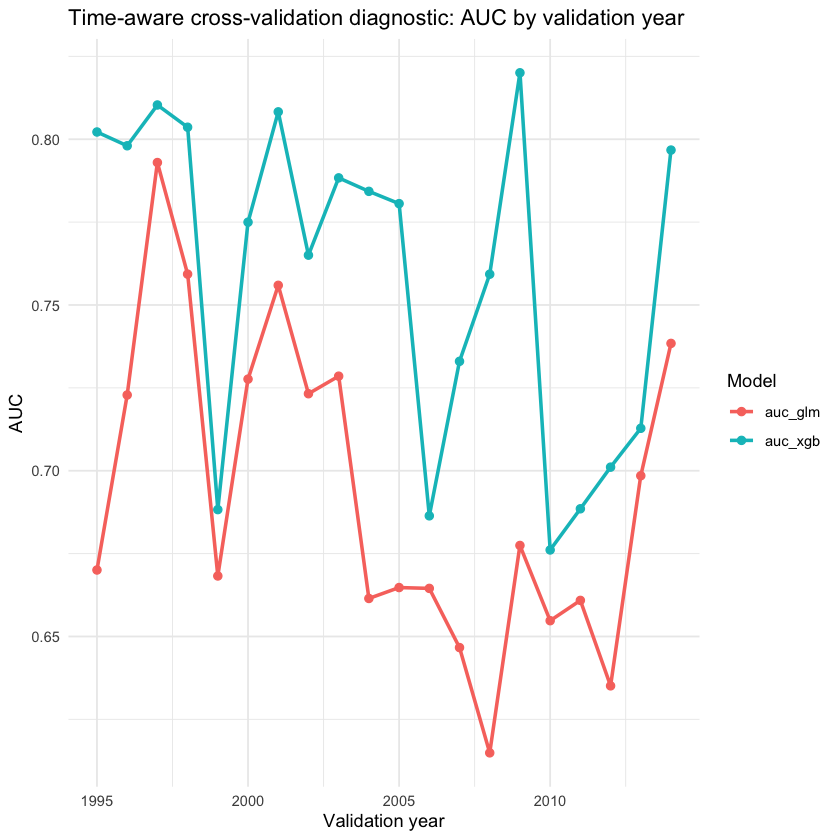

In [16]:
fold_long <- fold_results %>%
  pivot_longer(
    cols = c(auc_glm, auc_xgb),
    names_to = "model",
    values_to = "auc"
  )

ggplot(fold_long, aes(x = valid_year, y = auc, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Time-aware cross-validation diagnostic: AUC by validation year",
    x = "Validation year",
    y = "AUC",
    color = "Model"
  ) + 
  theme_minimal()

In [17]:
cat('Overall, XGboost outperforms logistic regression in AUC by ', 
    round(mean(fold_results$auc_xgb) / mean(fold_results$auc_glm) * 100, 2) - 100, "%", sep= '')

Overall, XGboost outperforms logistic regression in AUC by 9.46%

### Data

In [18]:
glimpse(model_df)

Rows: 147,576
Columns: 13
$ y_next      <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ lat_bin     <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin     <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67…
$ state       <fct> PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR, PR…
$ month_cos   <dbl> 8.660254e-01, 5.000000e-01, 6.123234e-17, -5.000000e-01, -…
$ month_sin   <dbl> 5.000000e-01, 8.660254e-01, 1.000000e+00, 8.660254e-01, 5.…
$ year        <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992…
$ n_fires     <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ fire_lag12  <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ fire_roll3  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ fire_roll12 <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ size_roll3  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ size_roll12 

In [19]:
years_sorted <- sort(unique(model_df$year))
min_train_years <- 3

feat_formula <- y_next ~ lat_bin + lon_bin + month_cos + month_sin + fire_roll12
features <- c("month_cos", "month_sin", "lat_bin", "lon_bin", "fire_roll12")
target <- "y_next"

fold_results <- tibble(
    train_end_year = years_sorted[(min_train_years):(length(years_sorted) - 2)],
    valid_year = years_sorted[(min_train_years + 1):(length(years_sorted) - 1)]) %>%
  mutate(
      # Logistic Regression
      auc_glm = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
          train <- model_df %>% filter(year <= tr_end)
          valid <- model_df %>% filter(year == va_year)
          ######### FILL IN THE MISSING PARTS #########
          fit <- glm(feat_formula, data = train, family = binomial)

          p_hat <- predict(fit, newdata = valid, type = "response")

          #########
          as.numeric(pROC::auc(pROC::roc(valid[[target]], p_hat, quiet = TRUE)))
      }),
     # Neural Network
      auc_nn = map2_dbl(train_end_year, valid_year, function(tr_end, va_year) {
        train <- model_df %>% filter(year <= tr_end)
        valid <- model_df %>% filter(year == va_year)
        ######### FILL IN THE MISSING PARTS #########

    # From rviews.rstudio.com: Preprocessing for NN
        #X_train <- as.matrix(X_train, byrow=TRUE)
        #X_train <- t(X_train)
        #y_train <- as.matrix(y_train, byrow=TRUE)
        #y_train <- t(y_train)
          
        x_train <- as.matrix(train[, features])
        y_train <- train[[target]]
        x_valid <- as.matrix(valid[, features])
        y_valid <- valid[[target]]

    # From rviews.rstudio.com: Preprocessing for NN
        #X_train <- scale(train[, c(1:2)])
        #y_train <- train$y
        #dim(y_train) <- c(length(y_train), 1) # add extra dimension to vector
        #X_test <- scale(test[, c(1:2)])
        #y_test <- test$y
        #dim(y_test) <- c(length(y_test), 1) # add extra dimension to vector

          
        x_mean <- colMeans(x_train)
        x_sd   <- apply(x_train, 2, sd)
        x_train_scaled <- scale(x_train, center = x_mean, scale = x_sd)
        x_valid_scaled <- scale(x_valid, center = x_mean, scale = x_sd)

        train_scaled <- as.data.frame(x_train_scaled)
        train_scaled[[target]] <- y_train

          
    #Fit neural networks: cran.r-project.org

          ## Default S3 method:
        #nnet(x, y, weights, size, Wts, mask,
        #linout = FALSE, entropy = FALSE, softmax = FALSE,
        #censored = FALSE, skip = FALSE, rang = 0.7, decay = 0,
        #maxit = 100, Hess = FALSE, trace = TRUE, MaxNWts = 1000,
        #abstol = 1.0e-4, reltol = 1.0e-8, ...)
        nn_model <- nnet::nnet(
          as.formula(paste(target, "~ .")),
          data    = train_scaled,
          size    = 8,
          decay   = 1e-4,     # L2  
          maxit   = 150,      # iterations
          linout  = FALSE,    #sigmoid
          rang    = 0.5,      
          skip    = FALSE,     
          MaxNWts = 5000,      
          abstol  = 1e-4,      
          reltol  = 1e-8,    
          trace   = FALSE
        )

        p_hat <- predict(nn_model, as.data.frame(x_valid_scaled), type = "raw")[, 1]
        #########

y_valid_num <- as.numeric(as.character(y_valid))

if (length(unique(y_valid_num)) < 2) return(NA_real_)

as.numeric(pROC::auc(pROC::roc(y_valid_num, p_hat, quiet = TRUE)))
      
      })
  )

In [20]:
fold_results


train_end_year,valid_year,auc_glm,auc_nn
<dbl>,<dbl>,<dbl>,<dbl>
1994,1995,0.6565903,0.6863444
1995,1996,0.6756359,0.7904572
1996,1997,0.8241479,0.7521758
1997,1998,0.7882271,0.7429082
1998,1999,0.6517699,0.7186242
1999,2000,0.6757945,0.7407086
2000,2001,0.7447745,0.7784928
2001,2002,0.6759542,0.7760247
2002,2003,0.7274770,0.8174031


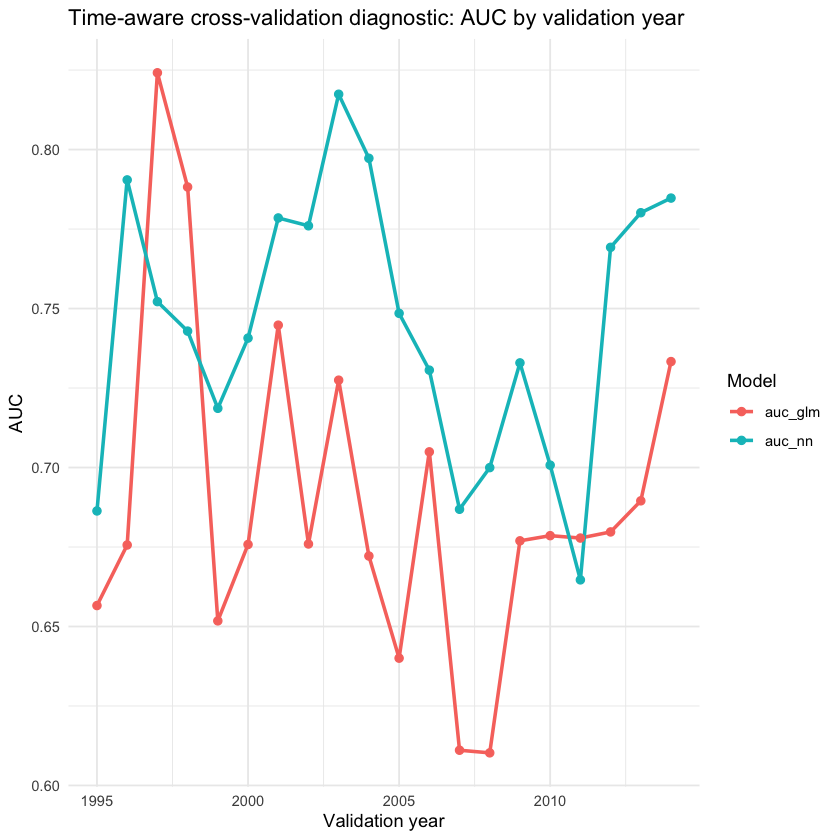

In [21]:
fold_long <- fold_results %>%
  pivot_longer(
    cols = c(auc_glm, auc_nn),
    names_to = "model",
    values_to = "auc"
  )

ggplot(fold_long, aes(x = valid_year, y = auc, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Time-aware cross-validation diagnostic: AUC by validation year",
    x = "Validation year",
    y = "AUC",
    color = "Model"
  ) + 
  theme_minimal()

In [22]:
range(model_df$year)

[1] 1992 2015

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine


Rows: 100000 Columns: 39
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (27): FPA_ID, SOURCE_SYSTEM_TYPE, SOURCE_SYSTEM, NWCG_REPORTING_AGENCY, ...
dbl (12): OBJECTID, FOD_ID, FIRE_YEAR, DISCOVERY_DATE, DISCOVERY_DOY, STAT_C...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


    OBJECTID           FOD_ID             FPA_ID          SOURCE_SYSTEM_TYPE
 Min.   :     16   Min.   :       16   Length:10089       Length:10089      
 1st Qu.: 311071   1st Qu.:   317268   Class :character   Class :character  
 Median :1097589   Median :  1336567   Mode  :character   Mode  :character  
 Mean   : 942048   Mean   : 58297392                                        
 3rd Qu.:1145056   3rd Qu.:  1395335                                        
 Max.   :1880464   Max.   :300348377                                        
                                                                            
 SOURCE_SYSTEM      NWCG_REPORTING_AGENCY NWCG_REPORTING_UNIT_ID
 Length:10089       Length:10089          Length:10089          
 Class :character   Class :character      Class :character      
 Mode  :character   Mode  :character      Mode  :character      
                                                                
                                                           

Rows: 10,089
Columns: 8
$ big_fire         <lgl> FALSE, FALSE, FALSE, FALSE, TRUE, FALSE, FALSE, FALSE…
$ FIRE_SIZE        <dbl> 0.10, 0.10, 0.10, 0.20, 27.90, 0.10, 0.50, 0.20, 0.10…
$ LATITUDE         <dbl> 38.56417, 37.04417, 34.25000, 39.57972, 35.65750, 38.…
$ LONGITUDE        <dbl> -120.5422, -119.3439, -117.6367, -121.1253, -118.0456…
$ month            <dbl> 10, 5, 7, 7, 8, 7, 8, 6, 8, 8, 8, 7, 9, 9, 7, 8, 9, 8…
$ year             <dbl> 2004, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005,…
$ STAT_CAUSE_DESCR <chr> "Lightning", "Equipment Use", "Miscellaneous", "Arson…
$ OWNER_DESCR      <chr> "USFS", "STATE OR PRIVATE", "USFS", "USFS", "USFS", "…


Warning message in randomForest.default(m, y, ...):
“The response has five or fewer unique values.  Are you sure you want to do regression?”



Call:
 randomForest(formula = big_fire ~ LATITUDE + LONGITUDE + month +      year + STAT_CAUSE_DESCR + OWNER_DESCR, data = ca_df, ntree = 200,      importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 200
No. of variables tried at each split: 2

          Mean of squared residuals: 0.1555532
                    % Var explained: 4.3

,%IncMSE,IncNodePurity
LATITUDE,36.28682,390.73453
LONGITUDE,32.77287,378.04722
month,16.51513,145.60481
year,26.89806,194.84292
STAT_CAUSE_DESCR,20.89182,98.24956
OWNER_DESCR,34.85403,79.06757


[1] 0

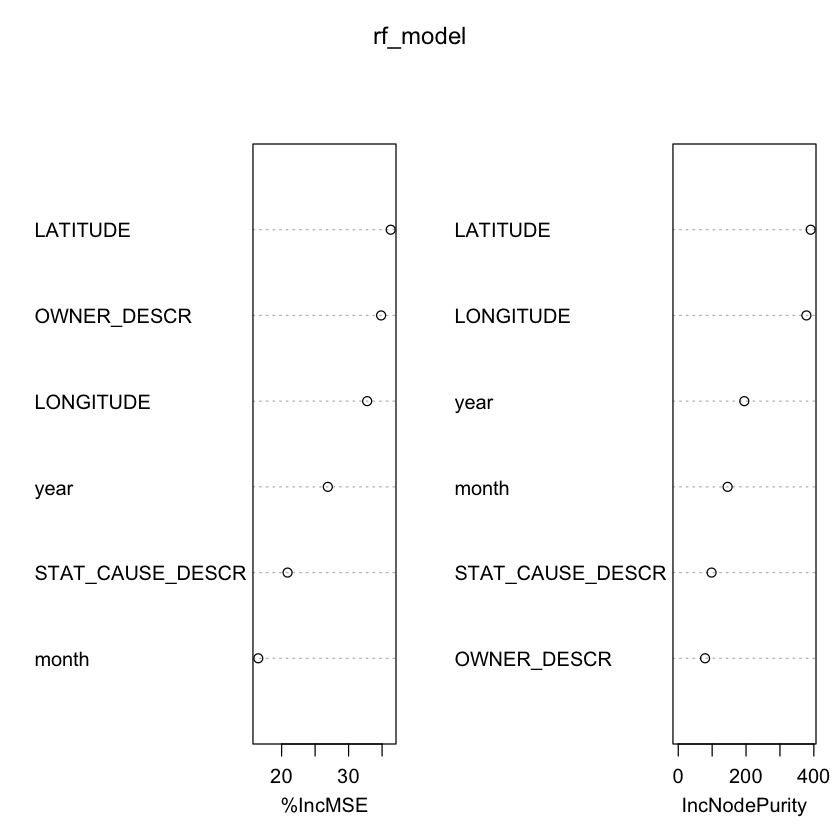

In [23]:
library(dplyr)
library(randomForest)

wildfires_full <- read_csv("wildfires_sample_100k.csv")
wildfires_ca <- wildfires_full %>%
  filter(STATE == "CA")

summary(wildfires_ca)


ca_df <- wildfires_ca %>%
  mutate(
    year  = FIRE_YEAR,
    month = floor((DISCOVERY_DOY - 1) / 30) + 1,
    big_fire = FIRE_SIZE > 1
  ) %>%
  select(
    big_fire,
    FIRE_SIZE,
    LATITUDE,
    LONGITUDE,
    month,
    year,
    STAT_CAUSE_DESCR,
    OWNER_DESCR
  ) %>%
  drop_na()


glimpse(ca_df)


set.seed(241)

rf_model <- randomForest(
  big_fire ~ LATITUDE + LONGITUDE + month + year +
             STAT_CAUSE_DESCR + OWNER_DESCR,
  data = ca_df,
  ntree = 200,
  importance = TRUE
)

rf_model


importance(rf_model)

varImpPlot(rf_model)

 

pred <- predict(rf_model, ca_df)

mean(pred == ca_df$big_fire)